Question 1: Generate daily dates (freq='D') from January 1, 2018, to January 15, 2018, using pd.date_range().

Question 2: Generate 10 business days (periods=10, freq='B') starting from March 1, 2018, using pd.date_range().

Question 3: Load nyc_weather.csv (assume it lacks dates) and set the date range from Q1 (15 dates) as its index using .set_index() or directly assigning it. (Note: Consider why an error occurs if the row count and date count do not match).

Question 4: Create a new random Pandas Series using np.random.randint(50, 100, ...) with the date range from Q1 as its index.

Question 5: Plot the Series from Q4 as a line chart using %matplotlib inline.

Question 6: Slice the data from "2018-01-05" to "2018-01-10" from the Series in Q4 using the colon : syntax (without using .loc).

Question 7: Run asfreq('D') on the Series from Q4 without passing method='pad'. Think about where NaN values would appear if there were gaps in the dates.

Question 8: Apply asfreq('D', method='pad') to the same Series and observe how the output differs from Q7.

Question 9: Run both resample('W').mean() and asfreq('W', method='pad') on the Series from Q4 and compare their outputs. Are they the same or different? (Concept check: Aggregation vs. Non-aggregation).

Question 10: Generate monthly dates (freq='M') from January 1, 2017, to January 1, 2018, using pd.date_range(). First guess how many dates will be generated, then confirm using code.

In [1]:
import pandas as pd
df = pd.read_csv("../datasets/aapl_no_dates.csv")
rng = pd.date_range(start="01-01-2018",end="01-15-2018",freq='D')
rng

DatetimeIndex(['2018-01-01', '2018-01-02', '2018-01-03', '2018-01-04',
               '2018-01-05', '2018-01-06', '2018-01-07', '2018-01-08',
               '2018-01-09', '2018-01-10', '2018-01-11', '2018-01-12',
               '2018-01-13', '2018-01-14', '2018-01-15'],
              dtype='datetime64[ns]', freq='D')

In [2]:
b_rng = pd.date_range(start="2018-03-01", periods=10, freq='B')
b_rng

DatetimeIndex(['2018-03-01', '2018-03-02', '2018-03-05', '2018-03-06',
               '2018-03-07', '2018-03-08', '2018-03-09', '2018-03-12',
               '2018-03-13', '2018-03-14'],
              dtype='datetime64[ns]', freq='B')

In [3]:
new_df = pd.read_csv("../datasets/nyc_weather.csv")
new_df = pd.date_range(start="2018-01-01", periods=len(df), freq='D')
df.set_index(new_df, inplace=True)
df.head(12)

,Open,High,Low,Close,Volume
2018-01-01,144.88,145.30,143.10,143.50,14277848
2018-01-02,143.69,144.79,142.72,144.09,21569557
2018-01-03,143.02,143.50,142.41,142.73,24128782
2018-01-04,142.90,144.75,142.90,144.18,19201712
2018-01-05,144.11,145.95,143.37,145.06,21090636
2018-01-06,144.73,145.85,144.38,145.53,19781836
2018-01-07,145.87,146.18,144.82,145.74,24884478
2018-01-08,145.50,148.49,145.44,147.77,25199373
2018-01-09,147.97,149.33,147.33,149.04,20132061
2018-01-10,148.82,150.90,148.57,149.56,23793456


In [4]:
import numpy as np
ts = pd.Series(np.random.randint(50, 100, len(new_df)), index=new_df)
ts

2018-01-01    77
2018-01-02    70
2018-01-03    90
2018-01-04    85
2018-01-05    76
2018-01-06    71
2018-01-07    51
2018-01-08    71
2018-01-09    98
2018-01-10    65
2018-01-11    54
2018-01-12    52
2018-01-13    57
2018-01-14    60
Freq: D, dtype: int32

<Axes: >

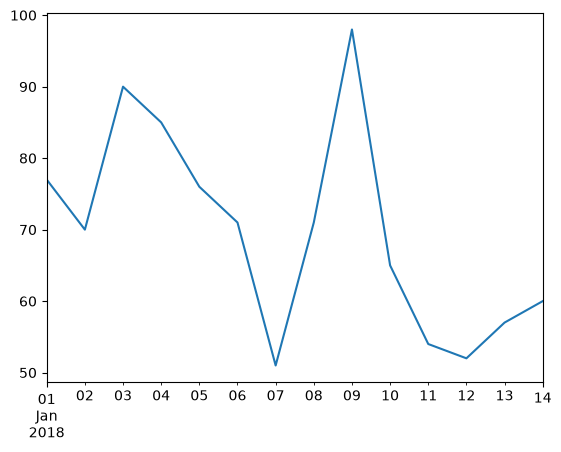

In [5]:
%matplotlib inline
ts.plot()

In [6]:
ts["2018-01-05":"2018-01-10"]

2018-01-05    76
2018-01-06    71
2018-01-07    51
2018-01-08    71
2018-01-09    98
2018-01-10    65
Freq: D, dtype: int32

In [7]:
ts.asfreq('W', method='pad')

2018-01-07    51
2018-01-14    60
Freq: W-SUN, dtype: int32

In [8]:
pd.date_range(start="2017-01-01", end="2018-01-01", freq='M')

C:\Users\ap504\AppData\Local\Temp\ipykernel_12868\1466328160.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.date_range(start="2017-01-01", end="2018-01-01", freq='M')


DatetimeIndex(['2017-01-31', '2017-02-28', '2017-03-31', '2017-04-30',
               '2017-05-31', '2017-06-30', '2017-07-31', '2017-08-31',
               '2017-09-30', '2017-10-31', '2017-11-30', '2017-12-31'],
              dtype='datetime64[ns]', freq='ME')